

### Credit card fraud

Credit card fraud is one of the most critical challenges facing banking and financial institutions today. The core issues lie in:

1. **Financial Losses:** Fraudulent transactions result in substantial financial damage to both banks and cardholders.
2. **Extreme Class Imbalance:** Fraudulent transactions represent a tiny fraction (less than 0.2%) of the overall volume. Traditional algorithms often yield misleadingly high accuracy while failing completely to detect actual fraud.
3. **Objective:** Build a robust Machine Learning model capable of detecting fraudulent transactions with high precision while minimizing False Positives, focusing on metrics such as **PR-AUC**, **Recall**, and **F1-Score**.

---

##### 📊 2. Dataset Overview

The dataset consists of credit card transactions, where sensitive customer features have been anonymized using Principal Component Analysis (**PCA**):

* **Shape:** Contains **170884** transactions.
* **Features Breakdown:**
  * `Time`: Number of seconds elapsed between the current transaction and the first transaction in the dataset.
  * `Amount`: The transaction amount in USD.
  * `V1` to `V28`: Numerical features transformed via **PCA** to protect confidentiality and privacy.
  * `Class` **(Target Variable):**
    * `0`: Legitimate / Normal Transaction.
    * `1`: Fraudulent Transaction.

---

##### ⚙️ 3. Key Challenges & Strategy

* **Class Imbalance:** Severe target skewness requires specialized handling (e.g., SMOTE, Class Weighting, or Undersampling).
* **Outliers & Skewness:** Features like `Amount` contain extreme values and heavy skewness, making `RobustScaler` the preferred choice for scaling.

In [1]:
import os
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt


In [2]:
file_path = "split/train.csv"


In [3]:
def Load_data(File_path=file_path):
    df = pd.read_csv(File_path)
    print(f"Data Loaded successfully! ..... {df.shape}")
    return df 


In [4]:
df = Load_data(file_path)


Data Loaded successfully! ..... (170884, 31)


In [5]:
def check_missing_values(df):
    missing_value = df.isna().sum()
    missing_value = missing_value[missing_value > 0]
    duplicate_rows = df.duplicated().sum()
    
    if missing_value.empty:
        print("No missing values found in the dataset.")
    else:
        print(f"Missing values in each column:\n{missing_value}")
    
    print(f"\nDuplicate rows count: {duplicate_rows}")
    return missing_value, duplicate_rows   


In [6]:
missing_values, duplicate_rows = check_missing_values(df)


No missing values found in the dataset.

Duplicate rows count: 448


In [7]:
if duplicate_rows > 0:
    print("\n--- Class distribution in duplicate rows ---")
    print(df[df.duplicated()]["Class"].value_counts())
    df.drop_duplicates(inplace=True)
    print(f"Shape after dropping duplicates: {df.shape}")



--- Class distribution in duplicate rows ---
Class
0    440
1      8
Name: count, dtype: int64
Shape after dropping duplicates: (170436, 31)


In [8]:
df["Hour"] = (df["Time"] // 3600) % 24

In [9]:
def info(df,col):
    print(f"--- Column: {col} ---")
    print(f"Data Type: {df[col].dtype}")
    print(f"Missing Values: {df[col].isna().sum()}")
    print(f"Number of Unique Values: {df[col].nunique()}")
    
    if df[col].nunique() <= 10:
        print(f"Unique Values: {df[col].unique()}")
    else:
        print(f"Min Value: {df[col].min()} | Max Value: {df[col].max()}")
        
    print(f"\nFirst 5 Values:\n{df[col].head().tolist()}")
    print("-" * 50)

In [10]:
info(df,"Time")
info(df,"Amount")
info(df,"Class")


--- Column: Time ---
Data Type: float64
Missing Values: 0
Number of Unique Values: 99277
Min Value: 0.0 | Max Value: 172792.0

First 5 Values:
[119191.0, 71750.0, 151977.0, 55709.0, 66654.0]
--------------------------------------------------
--- Column: Amount ---
Data Type: float64
Missing Values: 0
Number of Unique Values: 25361
Min Value: 0.0 | Max Value: 25691.16

First 5 Values:
[8.73, 59.95, 460.65, 4.78, 44.31]
--------------------------------------------------
--- Column: Class ---
Data Type: int64
Missing Values: 0
Number of Unique Values: 2
Unique Values: [0 1]

First 5 Values:
[0, 0, 0, 0, 0]
--------------------------------------------------


In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
count,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,...,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000,170436.000000
mean,94964.883252,0.003016,-0.003764,-0.001770,-0.004885,0.001359,-0.000109,0.000715,-0.002095,-0.001676,...,-0.000016,0.000579,-0.000780,-0.000788,-0.000671,0.001634,0.000775,88.596637,0.001743,14.052272
std,47458.729255,1.951034,1.646755,1.516106,1.415351,1.391759,1.337909,1.251332,1.191566,1.096377,...,0.725241,0.620362,0.605168,0.521052,0.481640,0.398607,0.313420,256.942683,0.041708,5.821871
min,0.000000,-46.855047,-63.344698,-48.325589,-5.683171,-113.743307,-23.496714,-43.557242,-73.216718,-13.434066,...,-10.933144,-36.666000,-2.836627,-7.081325,-2.604551,-9.895244,-15.430084,0.000000,0.000000,0.000000
25%,54355.000000,-0.919288,-0.600188,-0.896354,-0.850234,-0.690660,-0.769441,-0.553610,-0.209678,-0.642834,...,-0.543061,-0.160869,-0.354463,-0.318465,-0.327476,-0.070596,-0.052949,5.640000,0.000000,10.000000
50%,84923.500000,0.018437,0.064566,0.177007,-0.022444,-0.053562,-0.274847,0.040934,0.021147,-0.052595,...,0.006095,-0.010625,0.040433,0.016671,-0.051336,0.001601,0.011229,22.080000,0.000000,15.000000
75%,139388.000000,1.316771,0.799875,1.028136,0.735256,0.612154,0.399075,0.569308,0.325010,0.594459,...,0.528623,0.147974,0.437967,0.350126,0.240168,0.091825,0.078454,77.822500,0.000000,19.000000
max,172792.000000,2.451888,22.057729,4.226108,16.875344,34.099309,73.301626,120.589494,18.282168,10.392889,...,10.503090,22.528412,4.584549,6.070850,3.517346,31.612198,16.129609,25691.160000,1.000000,23.000000


##### 1. Target Imbalance (`Class`)
* **Mean Value:** The average of `Class` is **`0.001743`**, meaning only **~0.174%** of the transactions are fraudulent (Class 1).
* **Percentiles:** The **25%**, **50% (Median)**, and **75%** percentiles are all **`0.00`**.
* The dataset suffers from **extreme class imbalance**. Traditional accuracy will be a misleading metric. Evaluation must rely on **PR-AUC**, **Recall**, and **F1-Score**.
-----------------------------------------------
#####  2.Transaction Amount Insights (`Amount`)
* **Skewness & Outliers:** 
  * The **Mean** is **`$88.60`**, while the **Median (50%)** is only **`$22.08`**.
  * The **Max** value reaches **`$25,691.16`**, whereas 75% of transactions are below **`$77.82`**.
  * **Zero Values:** The **Min** value is **`$0.00`** (likely authorization checks or failed transfers).
  * `Amount` has extreme right-skewness and heavy outliers. Standard Scaling will fail; **`RobustScaler`** or a **`log1p` transformation** is   required.
-----------------------------------------------
##### 3. Time & Temporal Features (`Time` & `Hour`)
* **Time Span:** `Time` ranges from **`0.00`** to **`172,792`** seconds (~48 hours / 2 full days).
* **Hour Distribution:** The generated `Hour` feature spans **`0` to `23`** hours:
  * **25%:** Hour 10
  * **50% (Median):** Hour 15 (3 PM)
  * **75%:** Hour 19 (7 PM)
* Transactions peak during afternoon and evening hours, providing strong temporal patterns for fraud detection.

In [12]:
output_folder="EDA_plots"
os.makedirs(output_folder,exist_ok=True)
print(f" Folder '{output_folder}' is ready for saving plots!")

 Folder 'EDA_plots' is ready for saving plots!


✅ Saved: EDA_plots\Distribution of Time.png


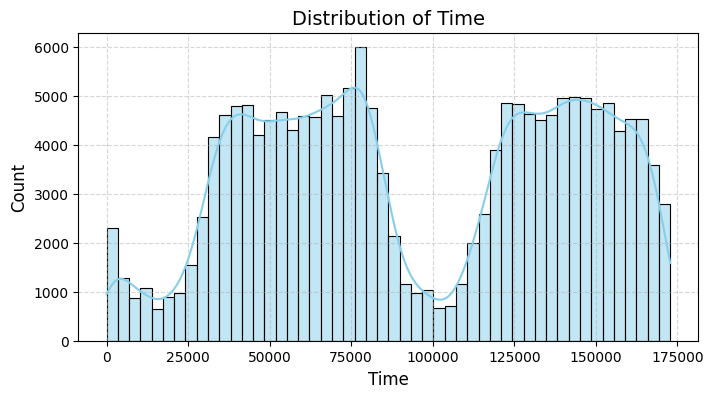

✅ Saved: EDA_plots\Distribution of Hour.png


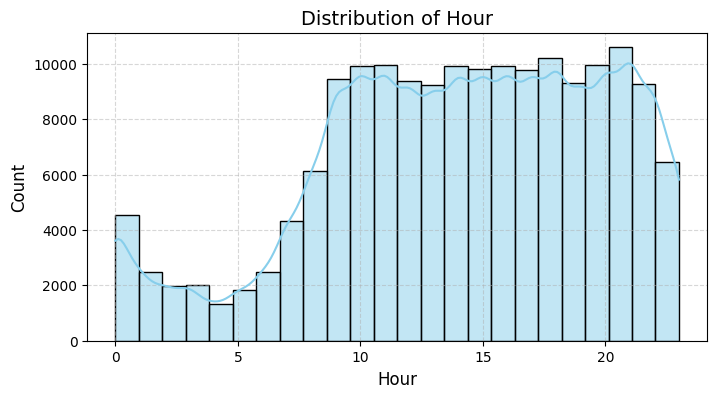

In [13]:
for col in ["Time", "Hour"]:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=col, data=df, kde=True, bins=24 if col == "Hour" else 50, color="skyblue")
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)
    plot_path=os.path.join(output_folder,f"Distribution of {col}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {plot_path}")
    plt.show()

 ##### 1. Time & Hour Distributions
* **Bimodal Time Pattern (`Distribution of Time`):** 
  * The dataset spans 2 consecutive days (~172,800 seconds).
  * Clear periodic drops occur between 100,000s–110,000s and 0s–25,000s, corresponding to **overnight hours** when transaction volume naturally plunges.
* **Daily Activity Cycle (`Distribution of Hour`):**
  * Transaction volume remains extremely low between **1 AM and 6 AM** (dropping below ~2,000 transactions/hour).
  * Activity surges starting at **8 AM** and stays consistently high throughout the day until **9 PM (Hour 21)**

✅ Saved: EDA_plots\Distribution of Log1p(Amount).png


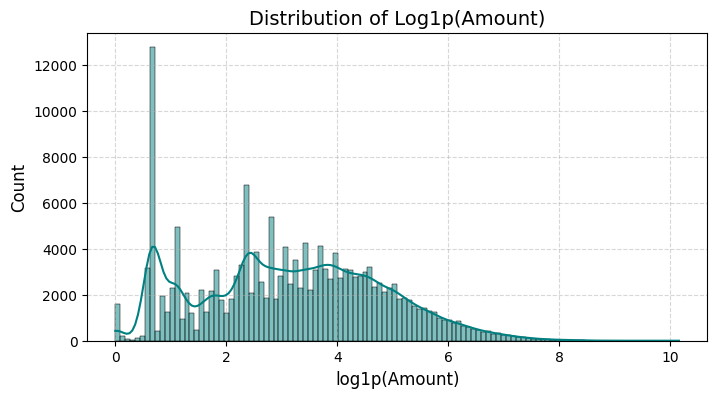

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(x=np.log1p(df["Amount"]), data=df, kde=True, color="teal")
plt.title("Distribution of Log1p(Amount)", fontsize=14)
plt.xlabel("log1p(Amount)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plot_path=os.path.join(output_folder,"Distribution of Log1p(Amount).png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {plot_path}")
plt.show()

 #### Transaction Amount Distributions
* **Multimodal Right-Skewed Data (`Distribution of Log1p(Amount)`):**
  * Applying the `log1p` transformation reveals distinct peaks around low-to-medium transaction values (e.g., $\approx 0.7$ and $2.3$ in log-scale).
  * The distribution exhibits a heavy right tail extending up to $10+$ in log-scale, confirming extreme high-value outliers.

✅ Saved: EDA_plots\Amount Distribution - Normal vs Fraud (Log Scale).png


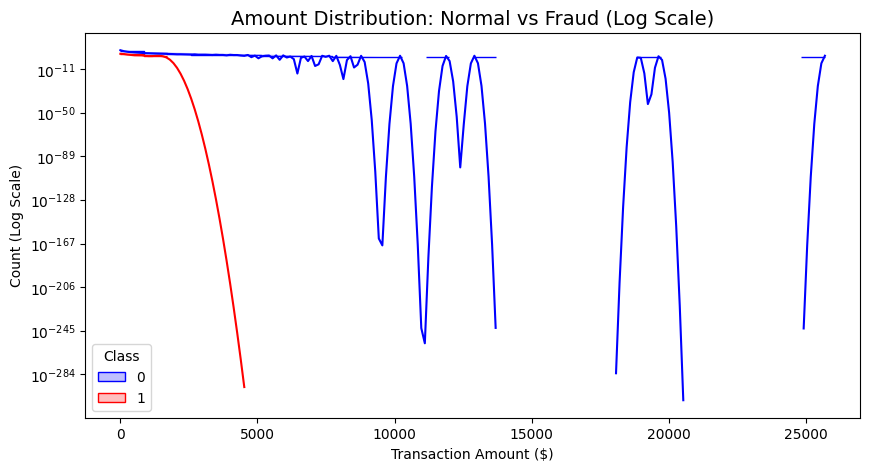

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df, 
    x="Amount", 
    hue="Class", 
    bins=30, 
    kde=True, 
    palette={0: "blue", 1: "red"}, 
    log_scale=(False, True),
    element="step" 
)

plt.title("Amount Distribution: Normal vs Fraud (Log Scale)", fontsize=14)
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Count (Log Scale)")

plot_path = os.path.join(output_folder, "Amount Distribution - Normal vs Fraud (Log Scale).png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {plot_path}")

plt.show()

* **Normal vs. Fraud Amount Behavior (`Amount Distribution: Normal vs Fraud`):**
  * **Fraud (Class 1):** Fraudulent transactions drop sharply as the transaction amount increases (confined mostly to smaller/medium values, terminating before $5,000$).
  * **Normal (Class 0):** Legitimate transactions span across all amount ranges, including extremely high amounts up to $25,000+$.

In [16]:
fraud_vs_normal_by_hour = pd.crosstab(df['Hour'], df['Class'])

print(fraud_vs_normal_by_hour)

Class      0   1
Hour            
0.0     4540   5
1.0     2472   8
2.0     1960  32
3.0     2016  10
4.0     1305  15
5.0     1839   7
6.0     2465   4
7.0     4324  16
8.0     6143   5
9.0     9463   9
10.0    9934   2
11.0    9942  31
12.0    9378  11
13.0    9213   9
14.0    9906  12
15.0    9814  18
16.0    9897  15
17.0    9766  16
18.0   10199  18
19.0    9284  15
20.0    9961  13
21.0   10590   8
22.0    9274   9
23.0    6454   9


✅ Saved successfully: EDA_plots\transactions_per_hour_lineplot.png


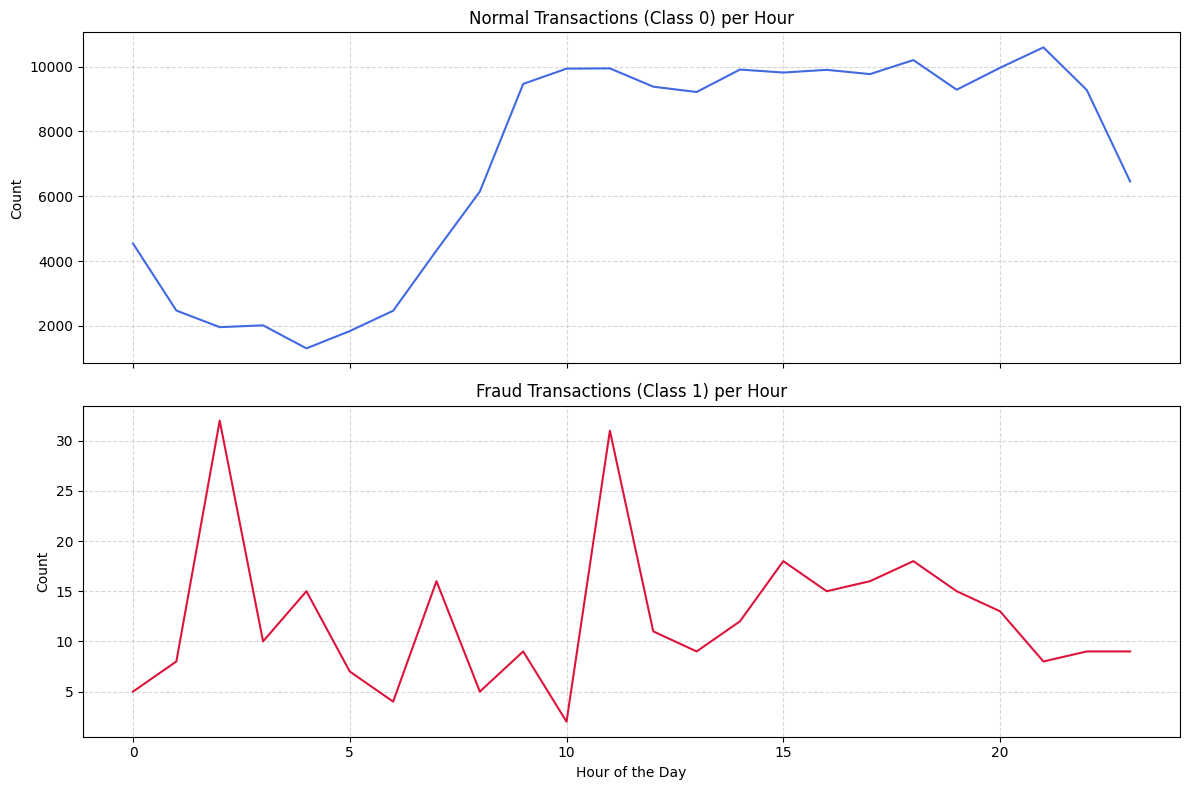

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(x=fraud_vs_normal_by_hour.index, y=fraud_vs_normal_by_hour[0], ax=axes[0], color='royalblue')
axes[0].set_title("Normal Transactions (Class 0) per Hour")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.lineplot(x=fraud_vs_normal_by_hour.index, y=fraud_vs_normal_by_hour[1], ax=axes[1], color='crimson')
axes[1].set_title("Fraud Transactions (Class 1) per Hour")
axes[1].set_xlabel("Hour of the Day")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plot_path = os.path.join(output_folder, "transactions_per_hour_lineplot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")
plt.show()



#### 1. Distinct Behavioral Patterns (Normal vs. Fraud)
* **Normal Transactions (Class 0):** Follow a predictable human activity cycle. Volume drops sharply past midnight, hitting a bottom (~1,300–2,000 transactions/hour) between **2 AM and 5 AM**, before surging rapidly from **8 AM to 9 PM** (hovering around ~9,000–10,500 transactions/hour).
* **Fraudulent Transactions (Class 1):** Do not follow standard business hours. High volume peaks occur during early morning hours—most notably at **Hour 2 (~32 fraud cases)** and **Hour 11 (~31 fraud cases)**.


---------------------------------------


In [18]:
fraud_rate_per_hour = df.groupby("Hour")["Class"].mean() * 100

print(fraud_rate_per_hour)

Hour
0.0     0.110011
1.0     0.322581
2.0     1.606426
3.0     0.493583
4.0     1.136364
5.0     0.379198
6.0     0.162009
7.0     0.368664
8.0     0.081327
9.0     0.095017
10.0    0.020129
11.0    0.310839
12.0    0.117158
13.0    0.097593
14.0    0.120992
15.0    0.183076
16.0    0.151332
17.0    0.163566
18.0    0.176177
19.0    0.161308
20.0    0.130339
21.0    0.075486
22.0    0.096951
23.0    0.139254
Name: Class, dtype: float64


✅ Saved successfully: EDA_plots\Fraud Rate Percentage by Hour of Day.png


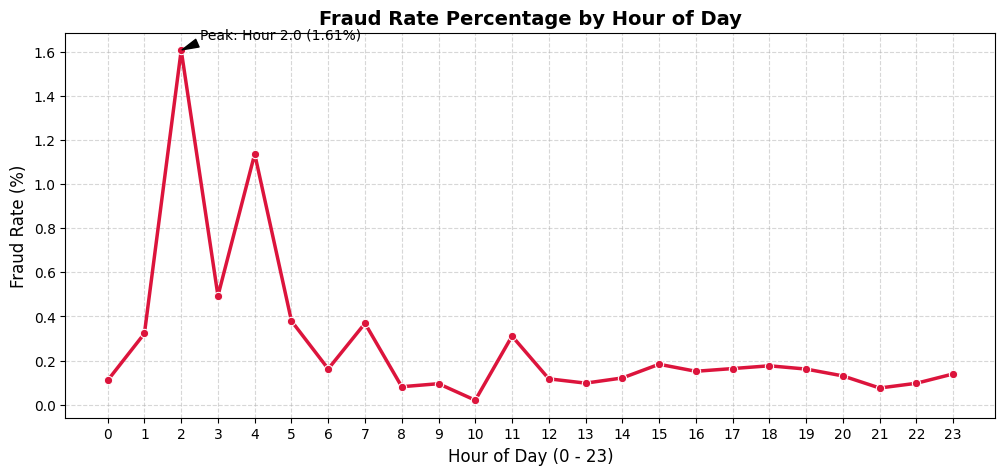

In [19]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=fraud_rate_per_hour.index, y=fraud_rate_per_hour.values, marker='o', color='crimson', linewidth=2.5)

plt.title("Fraud Rate Percentage by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day (0 - 23)", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.5)

max_hour = fraud_rate_per_hour.idxmax()
max_rate = fraud_rate_per_hour.max()
plt.annotate(f'Peak: Hour {max_hour} ({max_rate:.2f}%)', 
             xy=(max_hour, max_rate), 
             xytext=(max_hour + 0.5, max_rate + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plot_path = os.path.join(output_folder, "Fraud Rate Percentage by Hour of Day.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")
plt.show()

#### Fraud Rate Concentration (Risk Assessment)
* **Peak Risk Window (Late Night / Early Morning):** 
  * The **highest fraud rate occurs at Hour 2 (2:00 AM)**, reaching **1.61%** of all transactions in that hour.
  * Secondary spikes occur at **Hour 4 (~1.14%)** and **Hour 1 (~0.33%)**.
  * **Why?** Since legitimate transactions are at their lowest during these hours, fraudulent attempts account for a significantly higher proportion of total traffic.
* **Low Risk Window (Daytime):**
  * From **Hour 8 to Hour 23**, the fraud rate stabilizes at extremely low levels (mostly **under 0.2%**, dropping as low as **0.02% at Hour 10**). High legitimate volume dilutes the fraud percentage during daytime hours.

✅ Saved successfully: EDA_plots\Amount Distribution by Class (Log Scale).png


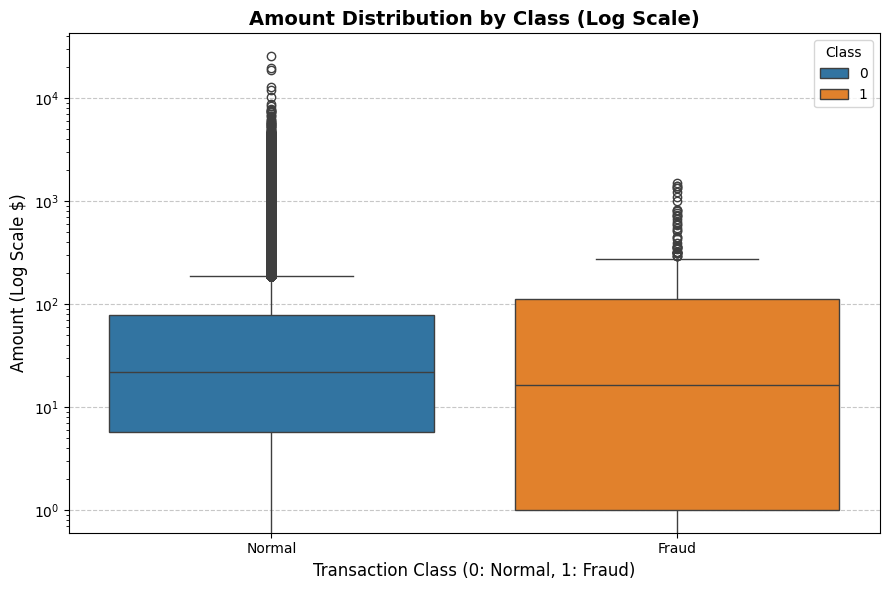

In [31]:

plt.figure(figsize=(9, 6))

ax = sns.boxplot(x="Class", y="Amount", data=df, hue="Class")

plt.yscale("log") 
plt.title("Amount Distribution by Class (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Class (0: Normal, 1: Fraud)", fontsize=12)
plt.ylabel("Amount (Log Scale $)", fontsize=12)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plot_path = os.path.join(output_folder, "Amount Distribution by Class (Log Scale).png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")
plt.show()

####  Amount Distribution (Log Scale)
* Scammers prefer medium and small amounts to avoid detection:

* The median amount is similar between the two (~$21 for normal transactions versus ~$17 for scams).

* The direct difference: Normal transactions have very high outliers (some exceeding $20,000).

* Scams, on the other hand, have outliers that stop at around $1,000 to $1,500, indicating that scams do not rely on very large amounts to avoid triggering bank alerts.

✅ Saved successfully: EDA_plots\Hours Distribution by Class.png


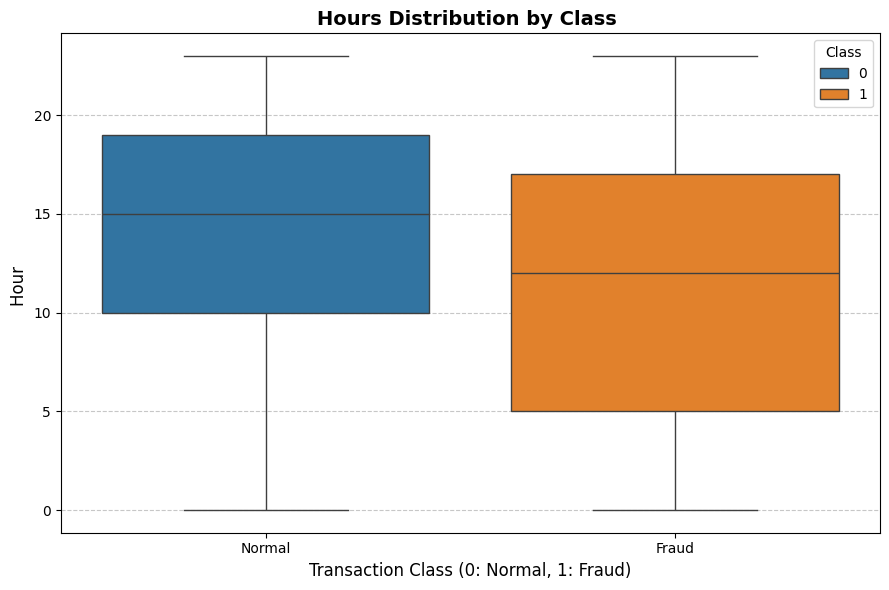

In [21]:

plt.figure(figsize=(9, 6))

ax = sns.boxplot(x="Class", y="Hour", data=df, hue="Class")


plt.title("Hours Distribution by Class ", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Class (0: Normal, 1: Fraud)", fontsize=12)
plt.ylabel("Hour ", fontsize=12)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plot_path = os.path.join(output_folder, "Hours Distribution by Class.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")
plt.show()

✅ Saved successfully: EDA_plots\Transactions Density by Hour- Fraud vs Normal.png


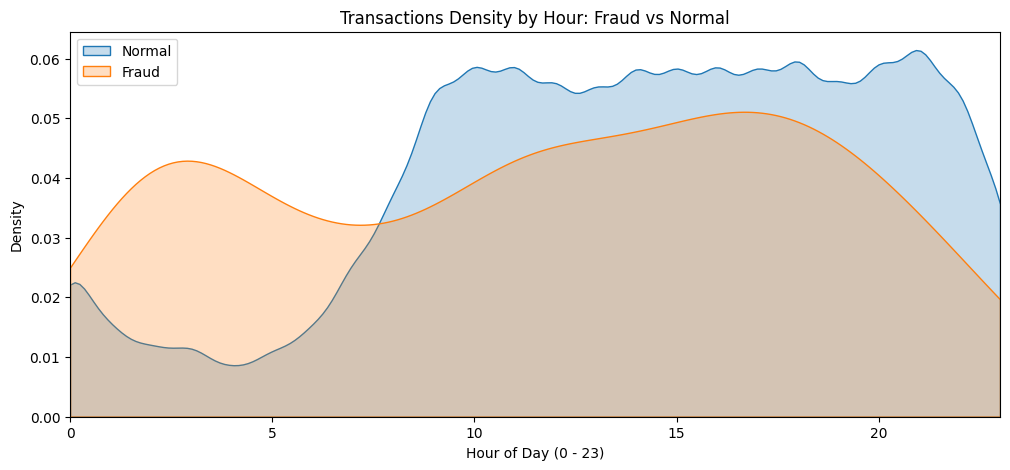

In [33]:
plt.figure(figsize=(12, 5))

sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Normal', fill=True, cut=0)
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraud', fill=True, cut=0)

plt.title('Transactions Density by Hour: Fraud vs Normal')
plt.xlabel('Hour of Day (0 - 23)')
plt.xlim(0, 23)   
plt.legend()

plot_path = os.path.join(output_folder, "Transactions Density by Hour- Fraud vs Normal.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")

plt.show()
plt.close() 

##### Hours Distribution by Class: Fraud activity expands at night and in the early morning:

* Normal transactions are heavily concentrated between 10 AM and 7 PM (IQR), with very low activity during sleep hours.

 * Fraud transactions, on the other hand, are widespread throughout the day, but are significantly concentrated in the early morning and late morning hours (from 0 AM to 6 AM),  * with the average fraud rate occurring around 12 PM, compared to 3 PM for normal transactions.
 * Fraud transactions exhibit a heavy concentration during early morning hours (1 AM – 5 AM), peaking around 3 AM, whereas normal transactions reach their lowest point during this timeframe. This confirms that Hour is a critical predictive feature for anomaly detection.

✅ Saved successfully: EDA_plots\pairplot_key_features.png


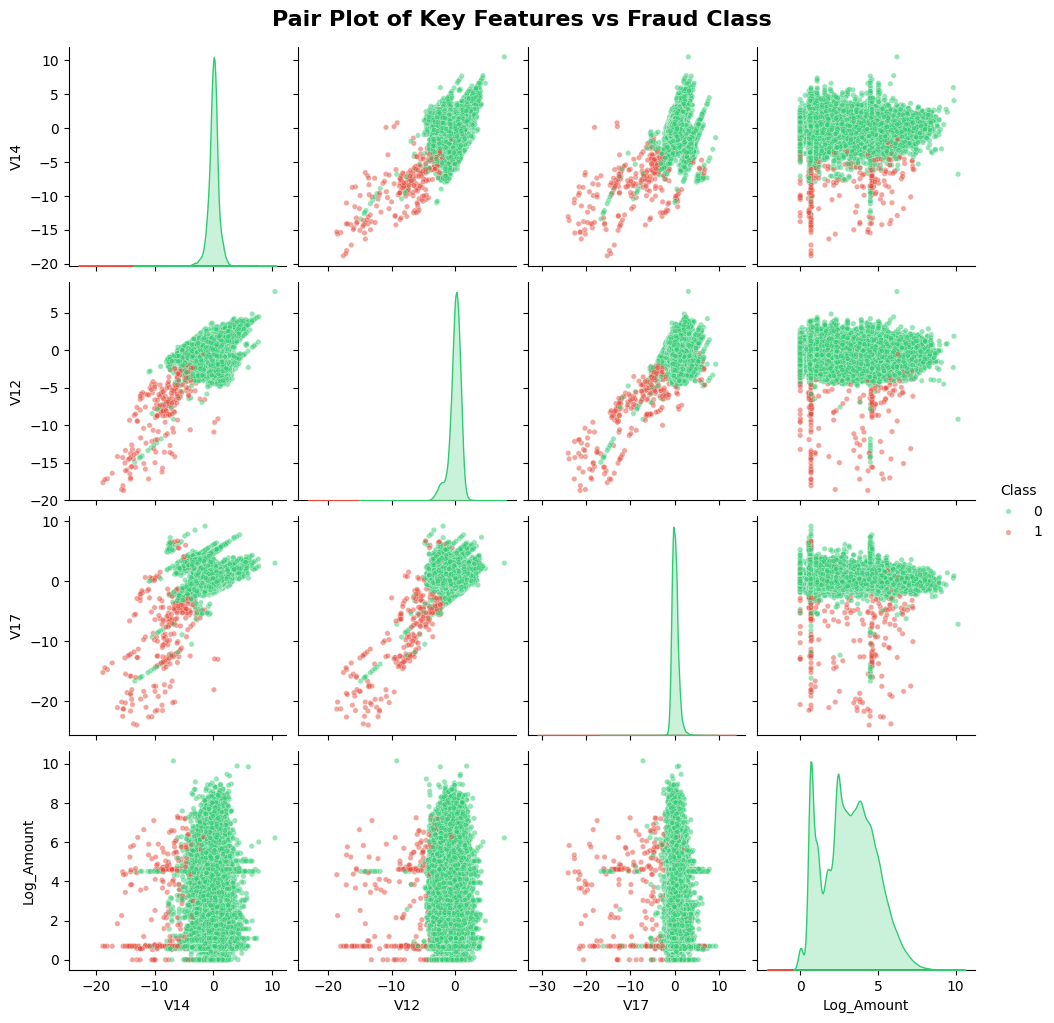

In [23]:
selected_features = ['V14', 'V12', 'V17', 'Amount', 'Class']
pairplot_df = df[selected_features].copy()
pairplot_df['Log_Amount'] = np.log1p(pairplot_df['Amount'])
pairplot_df = pairplot_df.drop(columns=['Amount'])

g = sns.pairplot(
    pairplot_df,
    hue='Class',
    palette={0: '#2ecc71', 1: '#e74c3c'}, 
    diag_kind='kde',                    
    plot_kws={'alpha': 0.5, 's': 15},    
    corner=False                          
)

g.fig.suptitle("Pair Plot of Key Features vs Fraud Class", y=1.02, fontsize=16, fontweight='bold')

plot_path = os.path.join(output_folder, "pairplot_key_features.png")
g.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")

plt.show()

####  Key Features Correlation & Distribution (`Pair Plot`)
* **Strong Segmentation in PCA Variables ($V_{14}, V_{12}, V_{17}$):**

* The variables $V_{14}$, $V_{12}$, and $V_{17}$ exhibit a strong divergence and very clear separation between the two groups. Fraud points (in red) are concentrated in the low negative values ​​(typically **below -$5**), while normal transactions (in green) are concentrated around zero and positive values.

* **Strong Correlation Between the Three Variables:**

* There is a clear positive linear relationship between $(V_{14}, V_{12})$ and $(V_{14}, V_{17})$ in fraud transactions, making this triad the most influential and decisive for the model to differentiate between transactions.

* **Weak impact of the amount alone:**

* The `Log_Amount` is distributed almost randomly and overlappingly across all ```.

✅ Saved successfully: EDA_plots\Correlation Matrix.png


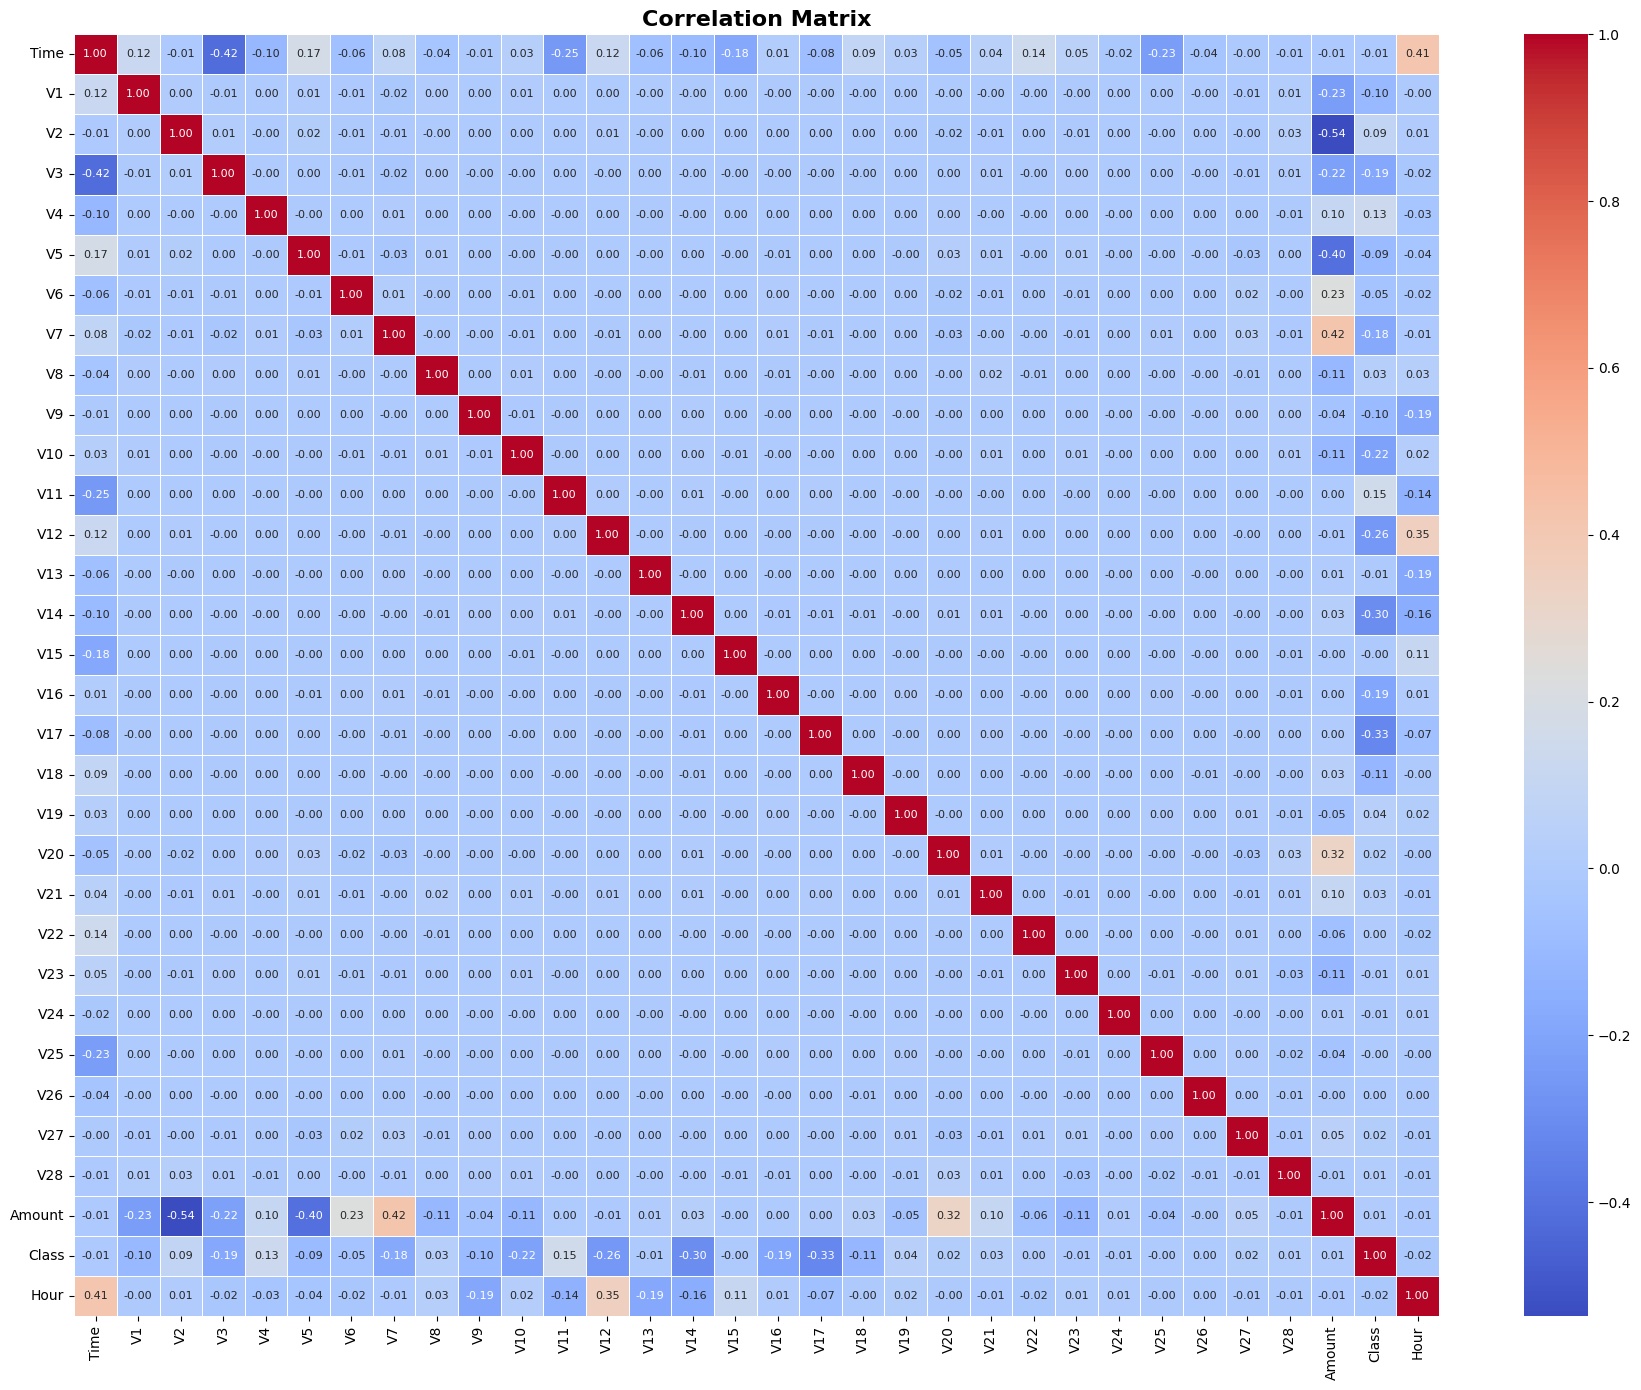

In [34]:
plt.figure(figsize=(18, 14))

corr = df.corr()

sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar=True,
    annot_kws={"size": 8},
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16, fontweight='bold')
plt.tight_layout()

plot_path = os.path.join(output_folder, "Correlation Matrix.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")

plt.show()

✅ Saved successfully: EDA_plots\Correlation of Features with Class (Fraud).png


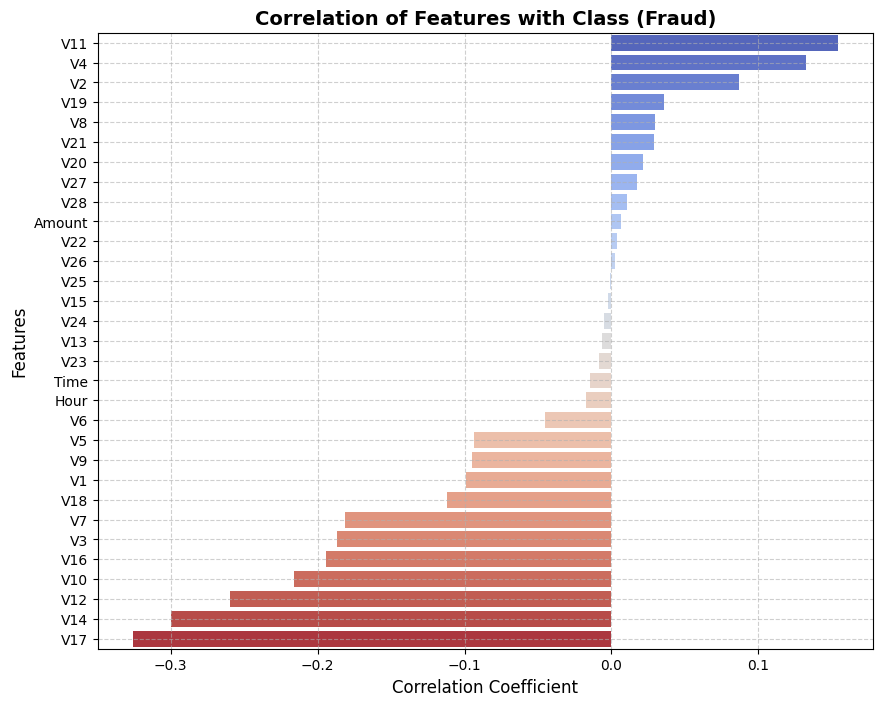

In [35]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_class.values, y=corr_with_class.index, hue=corr_with_class.index, palette="coolwarm", legend=False)
plt.title("Correlation of Features with Class (Fraud)", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plot_path = os.path.join(output_folder, "Correlation of Features with Class (Fraud).png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")

plt.show()

✅ Saved successfully: EDA_plots\Correlation with Class.png


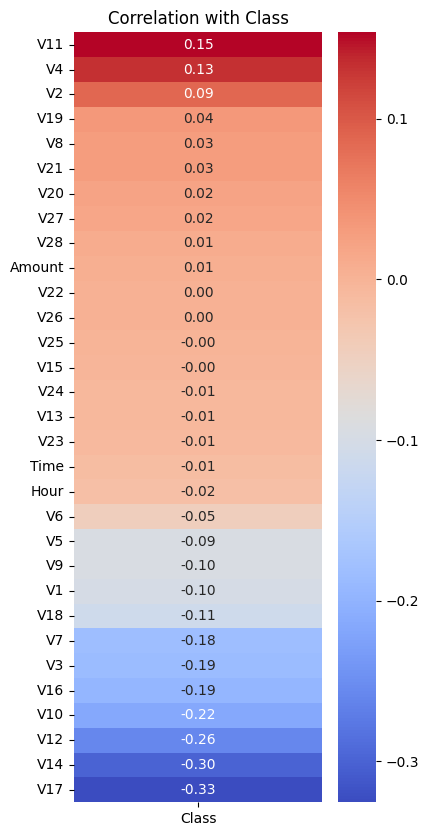

In [36]:
plt.figure(figsize=(4, 10))
sns.heatmap(corr_with_class.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Class")
plot_path = os.path.join(output_folder, "Correlation with Class.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved successfully: {plot_path}")
plt.show()

 #### 3. Feature Correlations with Target (`Class`)
* **Top Positive Correlations (Features that increase Fraud likelihood):**
  1. **`V11`** (+0.15): Strongest positive predictor.
  2. **`V4`** (+0.13)
  3. **`V2`** (+0.09)
  4. **`V19`** (+0.04)
* **Top Negative Correlations (Features that decrease Fraud likelihood):**
  1. **`V17`** (-0.32): Strongest overall signal in the dataset.
  2. **`V14`** (-0.30)
  3. **`V12`** (-0.26)
  4. **`V10`** (-0.22)
  5. **`V16`** (-0.19)
* **Weak / Neutral Predictors:**
  * `Amount` (+0.01), `Time` (-0.01), and `Hour` (-0.02) have near-zero linear correlation with `Class`, indicating that individual time and amount variables alone cannot linearly separate fraud from normal transactions without non-linear modeling.


In [27]:
os.makedirs("EDA_model", exist_ok=True)
df.to_pickle("EDA_model/cleaned_data.pkl")
print("Cleaned data saved to EDA_model/cleaned_data.pkl successfully!")

Cleaned data saved to EDA_model/cleaned_data.pkl successfully!
